In [9]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from collections import Counter

# Add project root to path so we can import our modules
sys.path.append('..')

print("Imports successful")

Imports successful


In [10]:
# Dataset paths
DATASET_1 = "../data/raw/oral-cancer-dataset/Oral Cancer/Oral Cancer Dataset"
DATASET_2 = "../data/raw/oral-cancer-dataset/Oral cancer Dataset 2.0/OC Dataset kaggle new"

ROOT_DIRS = [DATASET_1, DATASET_2]
CLASSES = ['CANCER', 'NON CANCER']

# Collect all image paths and labels
image_paths = []
labels = []

for root_dir in ROOT_DIRS:
    for class_name in CLASSES:
        class_dir = os.path.join(root_dir, class_name)
        if not os.path.exists(class_dir):
            print(f"Not found: {class_dir}")
            continue
        for img_file in sorted(os.listdir(class_dir)):
            if img_file.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
                image_paths.append(os.path.join(class_dir, img_file))
                labels.append(class_name)

print(f"Total images found: {len(image_paths)}")
print(f"Class distribution: {Counter(labels)}")

Total images found: 1700
Class distribution: Counter({'CANCER': 1000, 'NON CANCER': 700})


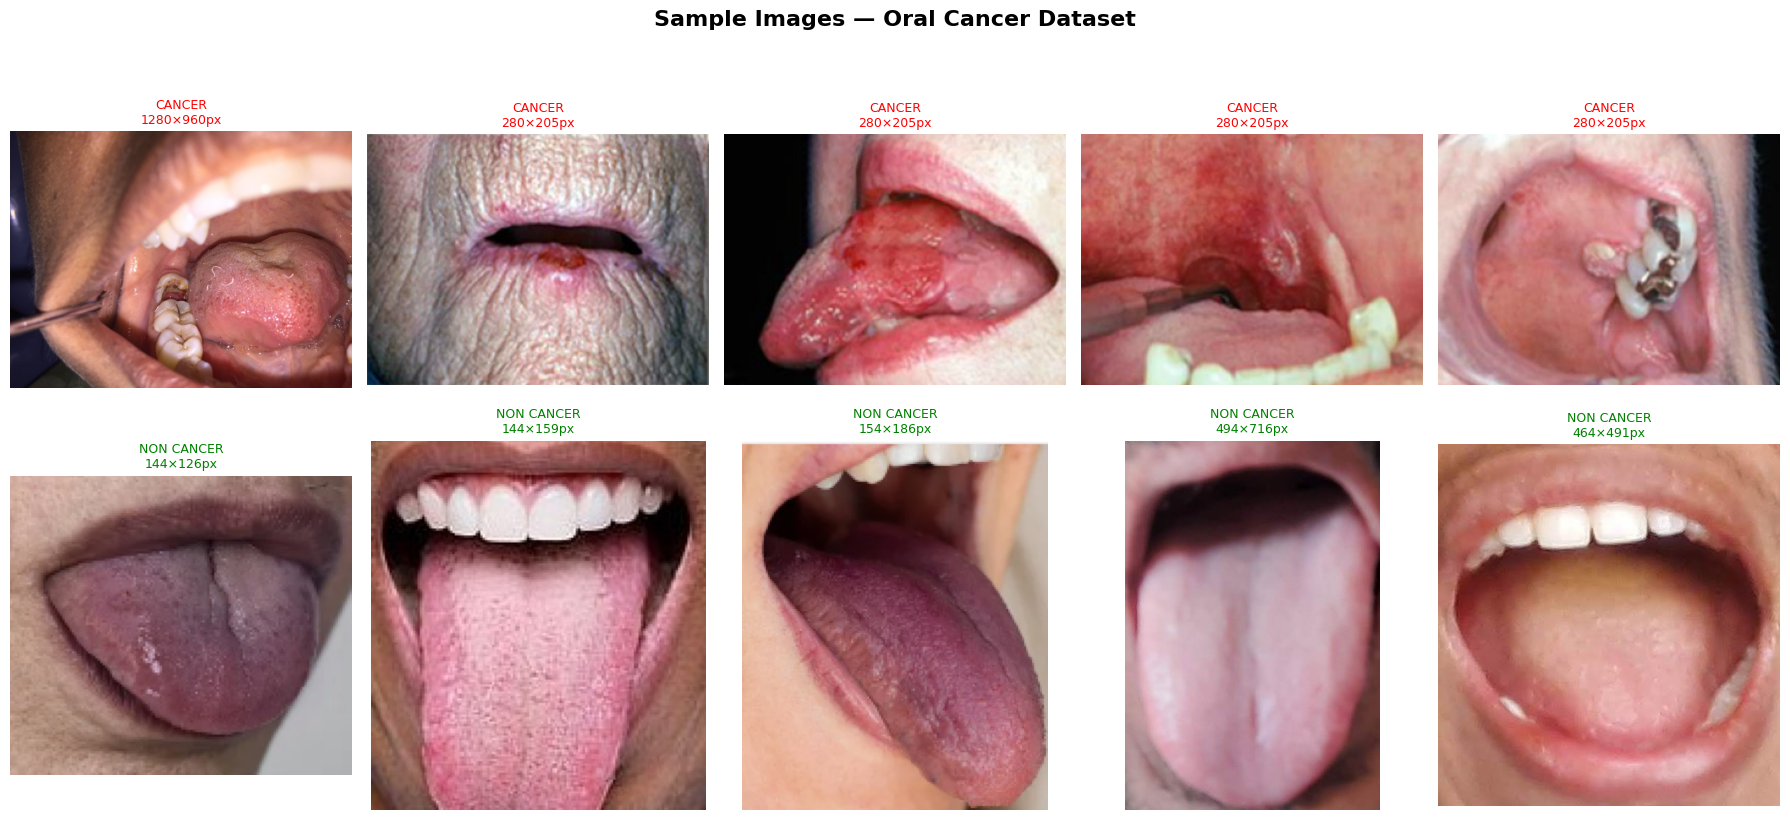

Sample images saved to results/sample_images.png


In [11]:
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
fig.suptitle("Sample Images — Oral Cancer Dataset", 
             fontsize=16, fontweight='bold', y=1.02)

for row, class_name in enumerate(CLASSES):
    class_paths = [p for p, l in zip(image_paths, labels) 
                   if l == class_name][:5]
    
    for col, path in enumerate(class_paths):
        img = Image.open(path).convert('RGB')
        axes[row, col].imshow(img)
        axes[row, col].set_title(
            f"{class_name}\n{img.size[0]}×{img.size[1]}px",
            fontsize=9, 
            color='red' if class_name == 'CANCER' else 'green'
        )
        axes[row, col].axis('off')

plt.tight_layout()
os.makedirs('../results', exist_ok=True)
plt.savefig('../results/sample_images.png', dpi=150, bbox_inches='tight')
plt.show()
print("Sample images saved to results/sample_images.png")

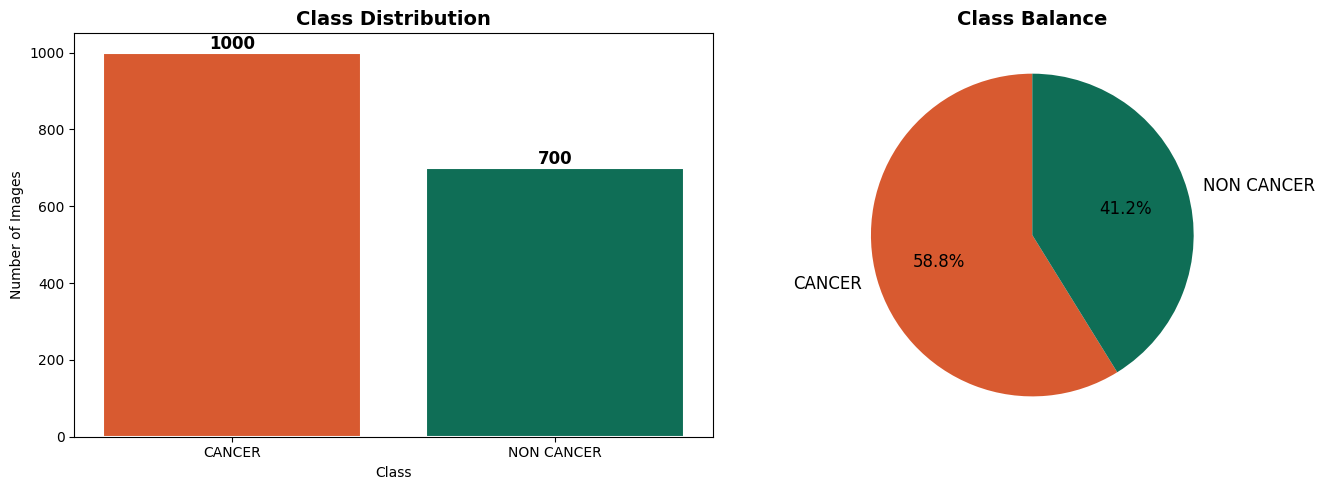

Class distribution saved
CANCER:     1000 images
NON CANCER: 700 images
Imbalance ratio: 1.43:1
Moderate imbalance — will use weighted sampling later


In [12]:
class_counts = Counter(labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors = ['#D85A30', '#0F6E56']
bars = axes[0].bar(class_counts.keys(), 
                    class_counts.values(), 
                    color=colors, 
                    edgecolor='white',
                    linewidth=1.5)
axes[0].set_title("Class Distribution", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Number of Images")
for bar, count in zip(bars, class_counts.values()):
    axes[0].text(bar.get_x() + bar.get_width()/2, 
                  bar.get_height() + 10,
                  str(count), ha='center', fontsize=12, fontweight='bold')

# Pie chart
axes[1].pie(class_counts.values(),
            labels=class_counts.keys(),
            colors=colors,
            autopct='%1.1f%%',
            startangle=90,
            textprops={'fontsize': 12})
axes[1].set_title("Class Balance", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../results/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Imbalance ratio
cancer = class_counts['CANCER']
non_cancer = class_counts['NON CANCER']
ratio = cancer / non_cancer
print(f"Class distribution saved")
print(f"CANCER:     {cancer} images")
print(f"NON CANCER: {non_cancer} images")
print(f"Imbalance ratio: {ratio:.2f}:1")
print(f"{'Moderate imbalance — will use weighted sampling later' if ratio > 1.2 else 'Classes roughly balanced'}")

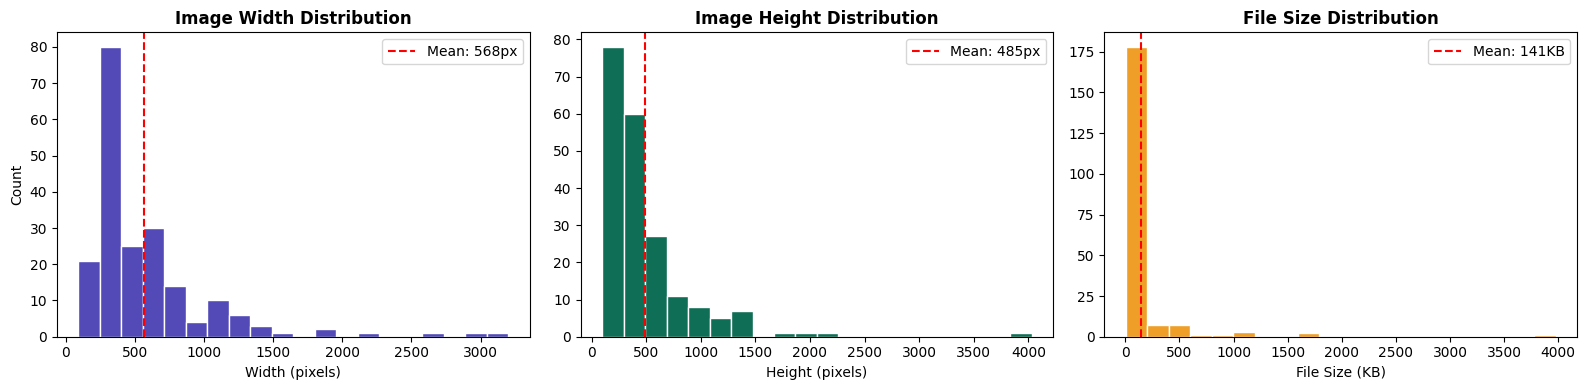

Image size analysis complete (sample of 200 images)
Width  — min: 93px  max: 3198px  mean: 568px
Height — min: 97px  max: 4032px  mean: 485px
Size   — min: 5KB  max: 3976KB  mean: 141KB
All images will be resized to 224×224px for training


In [13]:
widths, heights = [], []
file_sizes = []

# Sample 200 images for speed
sample_paths = image_paths[:200]

for path in sample_paths:
    img = Image.open(path)
    w, h = img.size
    widths.append(w)
    heights.append(h)
    file_sizes.append(os.path.getsize(path) / 1024)  # KB

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Width distribution
axes[0].hist(widths, bins=20, color='#534AB7', edgecolor='white')
axes[0].set_title("Image Width Distribution", fontweight='bold')
axes[0].set_xlabel("Width (pixels)")
axes[0].set_ylabel("Count")
axes[0].axvline(np.mean(widths), color='red', 
                 linestyle='--', label=f'Mean: {np.mean(widths):.0f}px')
axes[0].legend()

# Height distribution
axes[1].hist(heights, bins=20, color='#0F6E56', edgecolor='white')
axes[1].set_title("Image Height Distribution", fontweight='bold')
axes[1].set_xlabel("Height (pixels)")
axes[1].axvline(np.mean(heights), color='red',
                 linestyle='--', label=f'Mean: {np.mean(heights):.0f}px')
axes[1].legend()

# File size distribution
axes[2].hist(file_sizes, bins=20, color='#EF9F27', edgecolor='white')
axes[2].set_title("File Size Distribution", fontweight='bold')
axes[2].set_xlabel("File Size (KB)")
axes[2].axvline(np.mean(file_sizes), color='red',
                 linestyle='--', label=f'Mean: {np.mean(file_sizes):.0f}KB')
axes[2].legend()

plt.tight_layout()
plt.savefig('../results/image_size_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Image size analysis complete (sample of {len(sample_paths)} images)")
print(f"Width  — min: {min(widths)}px  max: {max(widths)}px  mean: {np.mean(widths):.0f}px")
print(f"Height — min: {min(heights)}px  max: {max(heights)}px  mean: {np.mean(heights):.0f}px")
print(f"Size   — min: {min(file_sizes):.0f}KB  max: {max(file_sizes):.0f}KB  mean: {np.mean(file_sizes):.0f}KB")
print(f"All images will be resized to 224×224px for training")

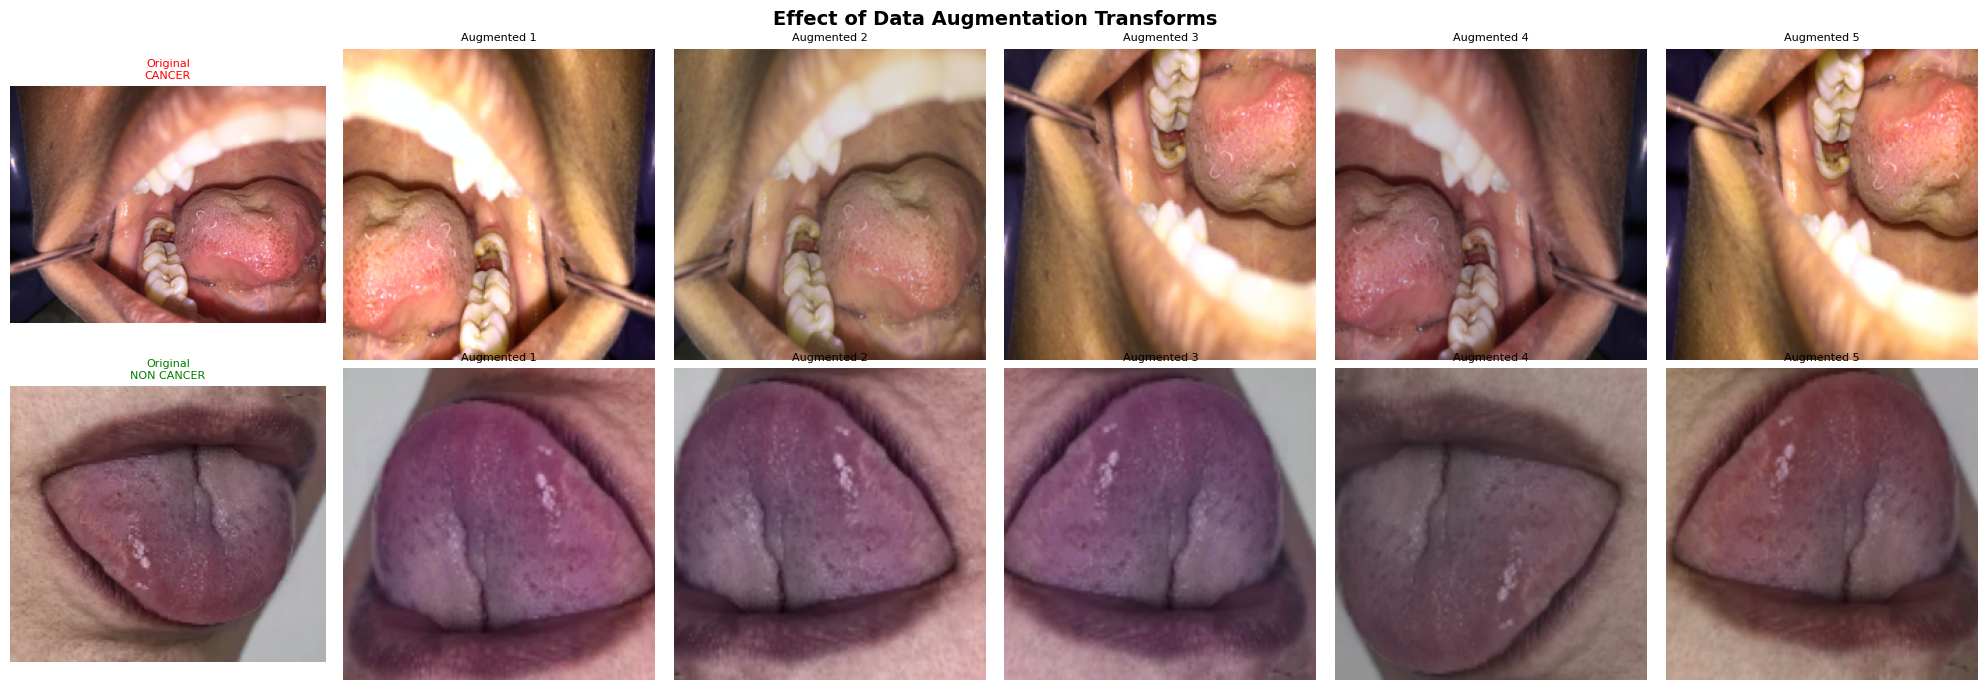

Augmentation examples saved
Each augmented version looks slightly different
This is what the model sees during each epoch


In [14]:
sys.path.insert(0, '..')
from data.dataset import get_transforms

# Pick one cancer and one non-cancer image
cancer_path = [p for p, l in zip(image_paths, labels) if l == 'CANCER'][0]
non_cancer_path = [p for p, l in zip(image_paths, labels) if l == 'NON CANCER'][0]

fig, axes = plt.subplots(2, 6, figsize=(20, 7))
fig.suptitle("Effect of Data Augmentation Transforms", 
             fontsize=14, fontweight='bold')

for row, (path, class_name) in enumerate(
        [(cancer_path, 'CANCER'), (non_cancer_path, 'NON CANCER')]):
    
    img = Image.open(path).convert('RGB')
    train_transform = get_transforms('train')
    
    # Original
    axes[row, 0].imshow(img)
    axes[row, 0].set_title(f"Original\n{class_name}", 
                            fontsize=8,
                            color='red' if class_name == 'CANCER' else 'green')
    axes[row, 0].axis('off')
    
    # 5 augmented versions
    for col in range(1, 6):
        augmented = train_transform(img).permute(1, 2, 0).numpy()
        # Denormalize for display
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        augmented = std * augmented + mean
        augmented = np.clip(augmented, 0, 1)
        
        axes[row, col].imshow(augmented)
        axes[row, col].set_title(f"Augmented {col}", fontsize=8)
        axes[row, col].axis('off')

plt.tight_layout()
plt.savefig('../results/augmentation_examples.png', dpi=150, bbox_inches='tight')
plt.show()
print("Augmentation examples saved")
print("Each augmented version looks slightly different")
print("This is what the model sees during each epoch")

In [15]:
from data.dataset import OralCancerDataset, get_transforms

# Initialize all three splits
train_ds = OralCancerDataset(ROOT_DIRS, 'train', get_transforms('train'))
val_ds   = OralCancerDataset(ROOT_DIRS, 'val',   get_transforms('val'))
test_ds  = OralCancerDataset(ROOT_DIRS, 'test',  get_transforms('test'))

# Summary
print("=" * 50)
print("FEDORAL-AI DATASET SUMMARY")
print("=" * 50)
print(f"Total images       : {len(image_paths)}")
print(f"CANCER           : {class_counts['CANCER']}")
print(f"NON CANCER       : {class_counts['NON CANCER']}")
print()
print(f"Train split        : {len(train_ds)} images (70%)")
print(f"Validation split   : {len(val_ds)} images (15%)")
print(f"Test split         : {len(test_ds)} images (15%)")
print()
print(f"Input tensor shape : {train_ds[0][0].shape}")
print(f"(channels=3, height=224, width=224)")
print()
print(f"Device             : MPS (Apple Silicon GPU)")
print(f"Batch size         : 32")
print(f"Steps per epoch    : {len(train_ds) // 32} steps")
print()
print(f"Results saved to   : ../results/")
print("=" * 50)

TRAIN set: 1190 images
VAL set: 255 images
TEST set: 255 images
FEDORAL-AI DATASET SUMMARY
Total images       : 1700
CANCER           : 1000
NON CANCER       : 700

Train split        : 1190 images (70%)
Validation split   : 255 images (15%)
Test split         : 255 images (15%)

Input tensor shape : torch.Size([3, 224, 224])
(channels=3, height=224, width=224)

Device             : MPS (Apple Silicon GPU)
Batch size         : 32
Steps per epoch    : 37 steps

Results saved to   : ../results/
